# Pipeline de Dados — EPE

### Objetivo:
Extrair e tratar o consumo mensal de energia elétrica por segmento e por Unidade da Federação, utilizado como proxy para a intensidade de uso de aquecimento de água nas diferentes regiões brasileiras.

### Segmentos extraídos:
- Residencial: proxy para uso de chuveiro elétrico
- Comercial:   proxy para hotéis, restaurantes e hospitais
- Industrial:  proxy para fábricas com demanda de água quente

### Fonte:
Empresa de Pesquisa Energética (EPE)
- Série histórica mensal de consumo de energia elétrica
por classe de consumidor e por UF, disponível em: https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/consumo-de-energia-eletrica
  - Abas utilizadas:
    - CONSUMO RESIDENCIAL POR UF,
    - CONSUMO COMERCIAL POR UF,
    - CONSUMO INDUSTRIAL POR UF
  - Período: 2021 a 2025 (compatível com dados do INMET)
  - Unidade: MWh

In [6]:
# ------------------------------------------------------------
# 1. MONTAGEM DO GOOGLE DRIVE
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# ------------------------------------------------------------
# 2. IMPORTAÇÃO DAS BIBLIOTECAS
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# ------------------------------------------------------------
# 3. CONFIGURAÇÃO
# Mapeamentos utilizados na limpeza e tratamento
# ------------------------------------------------------------

caminho = "/content/drive/MyDrive/dados_projeto_ciencia_dados/consumo_mensal_energia_eletrica_por_classe.xlsx"

# Abas de interesse e seus rótulos de segmento
SEGMENTOS = {
    "residencial" : "CONSUMO RESIDENCIAL POR UF",
    "comercial"   : "CONSUMO COMERCIAL POR UF",
    "industrial"  : "CONSUMO INDUSTRIAL POR UF"
}

# Mês por extensão → número
MAPA_MESES = {
    "JAN": 1, "FEV": 2, "MAR": 3, "ABR": 4,
    "MAI": 5, "JUN": 6, "JUL": 7, "AGO": 8,
    "SET": 9, "OUT": 10, "NOV": 11, "DEZ": 12
}

# Nome da UF no arquivo EPE → sigla padrão IBGE
MAPA_UF = {
    "Rondonia"        : "RO", "Acre"             : "AC",
    "Amazonas"        : "AM", "Roraima"          : "RR",
    "Para"            : "PA", "Amapa"            : "AP",
    "Tocantins"       : "TO", "Maranhao"         : "MA",
    "Piaui"           : "PI", "Ceara"            : "CE",
    "Rio Grande do Norte": "RN", "Paraiba"          : "PB",
    "Pernambuco"      : "PE", "Alagoas"          : "AL",
    "Sergipe"         : "SE", "Bahia"            : "BA",
    "Minas Gerais"    : "MG", "Espirito Santo"   : "ES",
    "Rio de Janeiro"  : "RJ", "Sao Paulo"        : "SP",
    "Parana"          : "PR", "Santa Catarina"   : "SC",
    "Rio Grande do Sul"  : "RS", "Mato Grosso do Sul" : "MS",
    "Mato Grosso"     : "MT", "Goias"            : "GO",
    "Distrito Federal": "DF"
}

In [9]:
# ------------------------------------------------------------
# 4. COLETA DOS DADOS
# Extração das abas de consumo por segmento e por UF
# ------------------------------------------------------------

def extrair_aba_epe(caminho, nome_aba, segmento):
    """
    Lê uma aba de consumo por UF do arquivo EPE.
    - Pula as 6 linhas de metadados
    - Constrói cabeçalho combinando ano e mês
    - Remove linha de total Brasil
    - Converte de formato largo para formato longo (tidy)
    - Aplica mapeamentos de mês e UF
    - Filtra período 2021 a 2025
    """
    df_raw = pd.read_excel(caminho, sheet_name=nome_aba, header=None)

    anos    = df_raw.iloc[4, 1:].astype(str).str.replace("*", "", regex=False)
    meses   = df_raw.iloc[5, 1:].astype(str)
    colunas = ["uf"] + [f"{a}_{m}" for a, m in zip(anos, meses)]

    df_dados = df_raw.iloc[6:].copy()
    df_dados.columns = colunas
    df_dados = df_dados[df_dados["uf"] != "TOTAL POR UF"].reset_index(drop=True)

    df_long = df_dados.melt(
        id_vars="uf",
        var_name="ano_mes",
        value_name="consumo_mwh"
    )

    df_long[["ano", "mes_abr"]] = df_long["ano_mes"].str.split("_", expand=True)
    df_long["ano"]         = pd.to_numeric(df_long["ano"], errors="coerce")
    df_long["mes"]         = df_long["mes_abr"].map(MAPA_MESES)
    df_long["consumo_mwh"] = pd.to_numeric(df_long["consumo_mwh"], errors="coerce")
    df_long["uf"]          = df_long["uf"].map(MAPA_UF)
    df_long["segmento"]    = segmento

    return (
        df_long[df_long["ano"].between(2021, 2025)]
        [["uf", "ano", "mes", "segmento", "consumo_mwh"]]
        .dropna()
        .reset_index(drop=True)
    )


# Carregar cada segmento e consolidar em um único DataFrame
lista_segmentos = [
    extrair_aba_epe(caminho, aba, seg)
    for seg, aba in SEGMENTOS.items()
]

df_epe_bruto = pd.concat(lista_segmentos, ignore_index=True)

print(f"Shape bruto consolidado: {df_epe_bruto.shape}")
print(df_epe_bruto["segmento"].value_counts())


Shape bruto consolidado: (4320, 5)
segmento
residencial    1440
comercial      1440
industrial     1440
Name: count, dtype: int64


In [10]:
# ------------------------------------------------------------
# 5. INSPEÇÃO INICIAL
# Verificar estrutura, tipos e volume dos dados
# ------------------------------------------------------------

print(df_epe_bruto.head(12))
print(df_epe_bruto.info())
print(df_epe_bruto.describe())


    uf   ano  mes     segmento  consumo_mwh
0   RO  2021    1  residencial   106564.524
1   AC  2021    1  residencial    47709.865
2   AM  2021    1  residencial   165005.000
3   RR  2021    1  residencial    41040.331
4   PA  2021    1  residencial   333372.982
5   AP  2021    1  residencial    47514.761
6   TO  2021    1  residencial    88112.462
7   MA  2021    1  residencial   302886.491
8   PI  2021    1  residencial   169186.364
9   CE  2021    1  residencial   448491.000
10  PB  2021    1  residencial   197316.465
11  PE  2021    1  residencial   488889.000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uf           4320 non-null   object 
 1   ano          4320 non-null   int64  
 2   mes          4320 non-null   int64  
 3   segmento     4320 non-null   object 
 4   consumo_mwh  4320 non-null   float64
dtypes: float64(1), int64(2)

In [11]:
# ------------------------------------------------------------
# 6. LIMPEZA E TRATAMENTO
# Verificar e remover registros inválidos
# ------------------------------------------------------------

df_epe = df_epe_bruto.copy()

# Verificar UFs não mapeadas
nulos_uf = df_epe["uf"].isna().sum()
print(f"\nRegistros com UF não mapeada: {nulos_uf}")

# Remover eventuais nulos remanescentes
antes = len(df_epe)
df_epe = df_epe.dropna().reset_index(drop=True)
print(f"Registros removidos: {antes - len(df_epe)}")
print(f"Shape após limpeza: {df_epe.shape}")

# Garantir que todas as 27 UFs foram mapeadas (nenhuma perdida silenciosamente)
assert df_epe["uf"].nunique() == 27, f'Esperadas 27 UFs, obtidas {df_epe["uf"].nunique()}'
print("OK: 27 UFs presentes.")



Registros com UF não mapeada: 0
Registros removidos: 0
Shape após limpeza: (4320, 5)


In [12]:
# ------------------------------------------------------------
# 7. VERIFICAÇÃO PÓS-LIMPEZA
# Confirmar integridade dos dados por segmento e UF
# ------------------------------------------------------------

print("\n=== VERIFICAÇÃO PÓS-LIMPEZA ===")
print(df_epe.groupby("segmento")["consumo_mwh"].describe())
print(f"\nUFs presentes: {sorted(df_epe['uf'].unique())}")
print(f"Anos presentes: {sorted(df_epe['ano'].unique())}")


=== VERIFICAÇÃO PÓS-LIMPEZA ===
              count           mean            std        min           25%  \
segmento                                                                     
comercial    1440.0  312129.525095  515659.623934  17329.449   66484.57775   
industrial   1440.0  615621.264653  989397.295998   1666.391   47410.94725   
residencial  1440.0  519840.846983  746032.378014  35021.876  147790.91450   

                     50%         75%          max  
segmento                                           
comercial    155971.2250  282365.826  3010012.584  
industrial   215563.4425  749179.328  4611874.823  
residencial  283589.9590  572366.954  4536421.459  

UFs presentes: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RO', 'RR', 'SC', 'SE', 'SP', 'TO']
Anos presentes: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


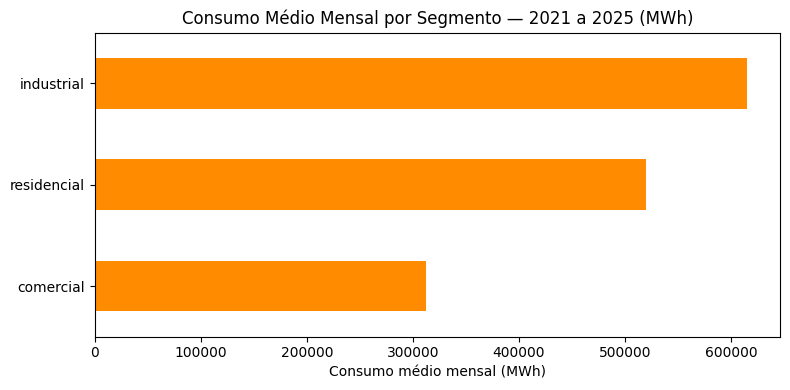

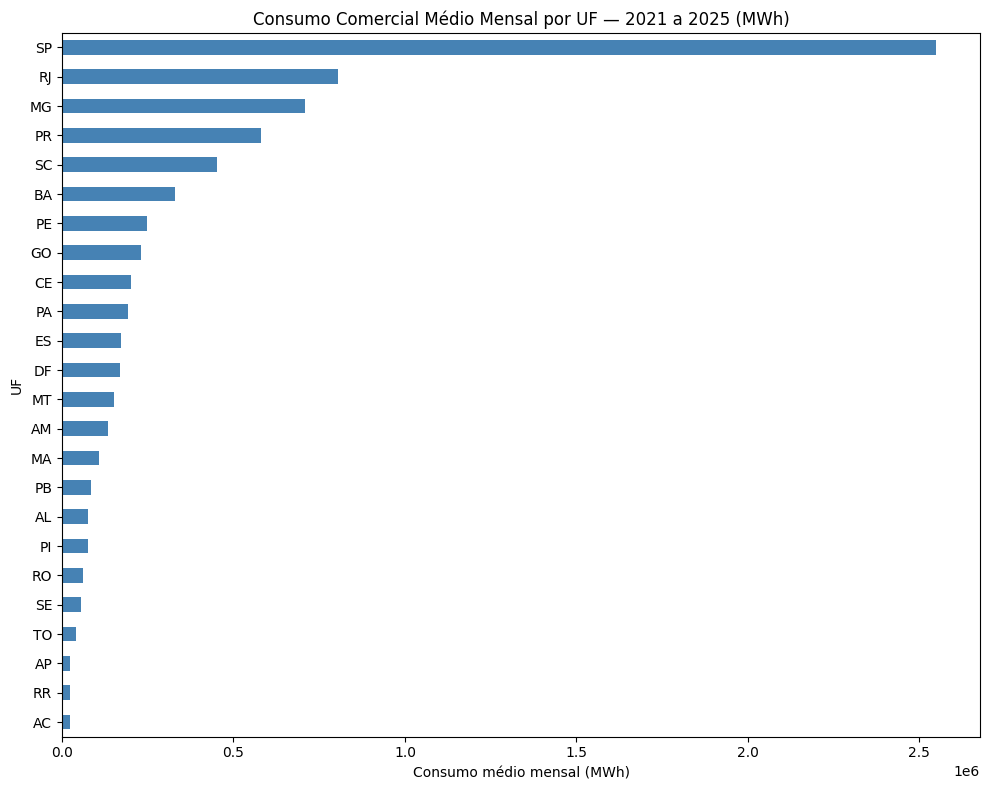

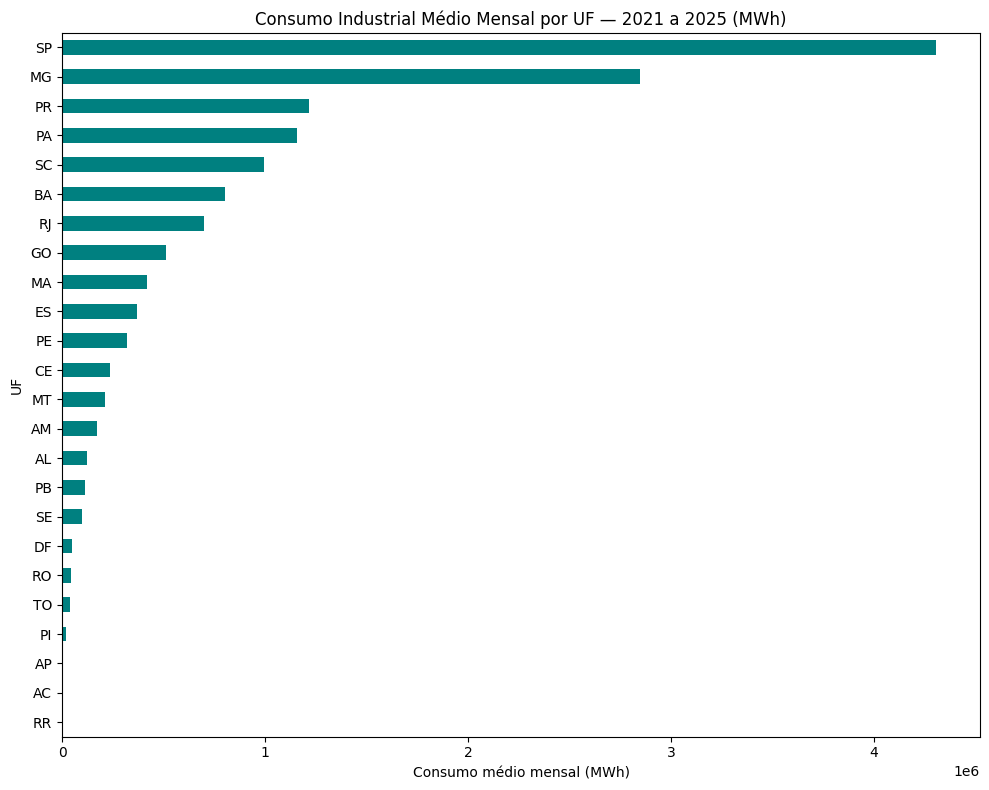

In [13]:
# ------------------------------------------------------------
# 8. VISUALIZAÇÕES INICIAIS
# Qual segmento concentra maior consumo médio por UF?
# ------------------------------------------------------------

df_consumo_seg = (
    df_epe
    .groupby("segmento")["consumo_mwh"]
    .mean()
    .sort_values(ascending=True)
)

df_consumo_seg.plot(kind="barh", figsize=(8, 4), color="darkorange")
plt.title("Consumo Médio Mensal por Segmento — 2021 a 2025 (MWh)")
plt.xlabel("Consumo médio mensal (MWh)")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Qual UF tem maior consumo comercial médio mensal?
# Proxy para concentração de hotéis, restaurantes e hospitais
df_consumo_comercial = (
    df_epe[df_epe["segmento"] == "comercial"]
    .groupby("uf")["consumo_mwh"]
    .mean()
    .sort_values(ascending=True)
)

df_consumo_comercial.plot(kind="barh", figsize=(10, 8), color="steelblue")
plt.title("Consumo Comercial Médio Mensal por UF — 2021 a 2025 (MWh)")
plt.xlabel("Consumo médio mensal (MWh)")
plt.ylabel("UF")
plt.tight_layout()
plt.show()


# Qual UF tem maior consumo industrial médio mensal?
# Proxy para concentração de fábricas com demanda de água quente
df_consumo_industrial = (
    df_epe[df_epe["segmento"] == "industrial"]
    .groupby("uf")["consumo_mwh"]
    .mean()
    .sort_values(ascending=True)
)

df_consumo_industrial.plot(kind="barh", figsize=(10, 8), color="teal")
plt.title("Consumo Industrial Médio Mensal por UF — 2021 a 2025 (MWh)")
plt.xlabel("Consumo médio mensal (MWh)")
plt.ylabel("UF")
plt.tight_layout()
plt.show()

In [14]:
# ------------------------------------------------------------
# 9. EXPORTAÇÃO
# Salvar dados tratados em CSV para uso nas etapas seguintes
# ------------------------------------------------------------

df_epe.to_csv(
    "/content/drive/MyDrive/dados_projeto_ciencia_dados/epe_consumo_por_segmento_uf.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo exportado com sucesso.")

Arquivo exportado com sucesso.
